In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from plant_shape_analysis.data_preprocessing.process_gt_TrackPlant3D  import custom_trimmed_poisson
from plant_shape_analysis.dataloaders.trackplant3D import LeafSequencesDataset
from plant_shape_analysis.vis.plot_functions import visualize_leaf_sequence

%load_ext autoreload
%autoreload 2

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Get GT data

We review the manual quality assesment of the dense point cloud data to only compute traits for the good leaves for now

In [2]:
base_path = Path("../data/TrackPlant3D")
qa_csv = base_path / "dense_leaves" / "dense_leaves_quality_assesment.csv"
df = pd.read_csv(qa_csv, delimiter=';')
df.head()

,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN
1,1,1,1_maize_control_plant1_D00_leaf2_dense,maize,control,1,0,2,bad,large holes
2,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN
3,3,1,2_maize_control_plant1_D01_leaf2_dense,maize,control,1,1,2,bad,poor segmentation
4,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN


In [3]:
good_leaves = df.loc[df['quality'] == 'good'].reset_index(drop=True)
good_leaves

,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN
1,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN
2,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN
3,7,0,4_maize_control_plant1_D03_leaf1_dense,maize,control,1,3,1,good,NaN
4,8,1,4_maize_control_plant1_D03_leaf2_dense,maize,control,1,3,2,good,NaN
...,...,...,...,...,...,...,...,...,...,...
88,200,32,376_tomato2_control_plant3_D06_leaf2_dense,tomato2,control,3,6,2,good,"small noise - apply SOR(nb=50,std=10) - remove..."
89,201,33,376_tomato2_control_plant3_D06_leaf3_dense,tomato2,control,3,6,3,good,"small noise - apply SOR(nb=50,std=10) - remove..."
90,205,31,377_tomato2_control_plant3_D07_leaf1_dense,tomato2,control,3,7,1,good,"small noise - apply SOR(nb=50,std=10) - remove..."
91,207,33,377_tomato2_control_plant3_D07_leaf3_dense,tomato2,control,3,7,3,good,"small noise - apply SOR(nb=50,std=10) - remove..."


#### Add leaf area to dataframe

In [4]:
# Load the JSON data with surface area measurements for all crops
surface_dict = {}

# Load maize data
json_path_maize = base_path / "dense_leaf_meshes" / "maize" / "processing_results.json"
with open(json_path_maize, 'r') as f:
    surface_data_maize = json.load(f)

for entry in surface_data_maize:
    filename = entry['leaf_file'].replace('.ply', '')
    surface_dict[filename] = entry['surface_area']

# Load tomato data  
json_path_tomato = base_path / "dense_leaf_meshes" / "tomato" / "processing_results.json"
with open(json_path_tomato, 'r') as f:
    surface_data_tomato = json.load(f)

for entry in surface_data_tomato:
    filename = entry['leaf_file'].replace('.ply', '')
    surface_dict[filename] = entry['surface_area']

# Add surface area column to good_leaves DataFrame
good_leaves['surface_area_mm2'] = good_leaves['file_name'].map(surface_dict)

# Filter out rows where surface area data is missing
plot_df = good_leaves.dropna(subset=['surface_area_mm2']).copy()

print(f"Found surface area data for {len(plot_df)} out of {len(good_leaves)} good leaves")
print("Crop distribution in plot data:")
print(plot_df['crop'].value_counts())
plot_df.head()

Found surface area data for 93 out of 93 good leaves
Crop distribution in plot data:
crop
tomato2    56
maize      37
Name: count, dtype: int64


,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment,surface_area_mm2
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN,495.334281
1,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN,487.358933
2,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN,480.708181
3,7,0,4_maize_control_plant1_D03_leaf1_dense,maize,control,1,3,1,good,NaN,483.115097
4,8,1,4_maize_control_plant1_D03_leaf2_dense,maize,control,1,3,2,good,NaN,1099.338830


#### Plot leaf area time series


MAIZE - Plants: [np.int64(1), np.int64(2), np.int64(3)], Leaf numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

TOMATO2 - Plants: [np.int64(1), np.int64(2), np.int64(3)], Leaf numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


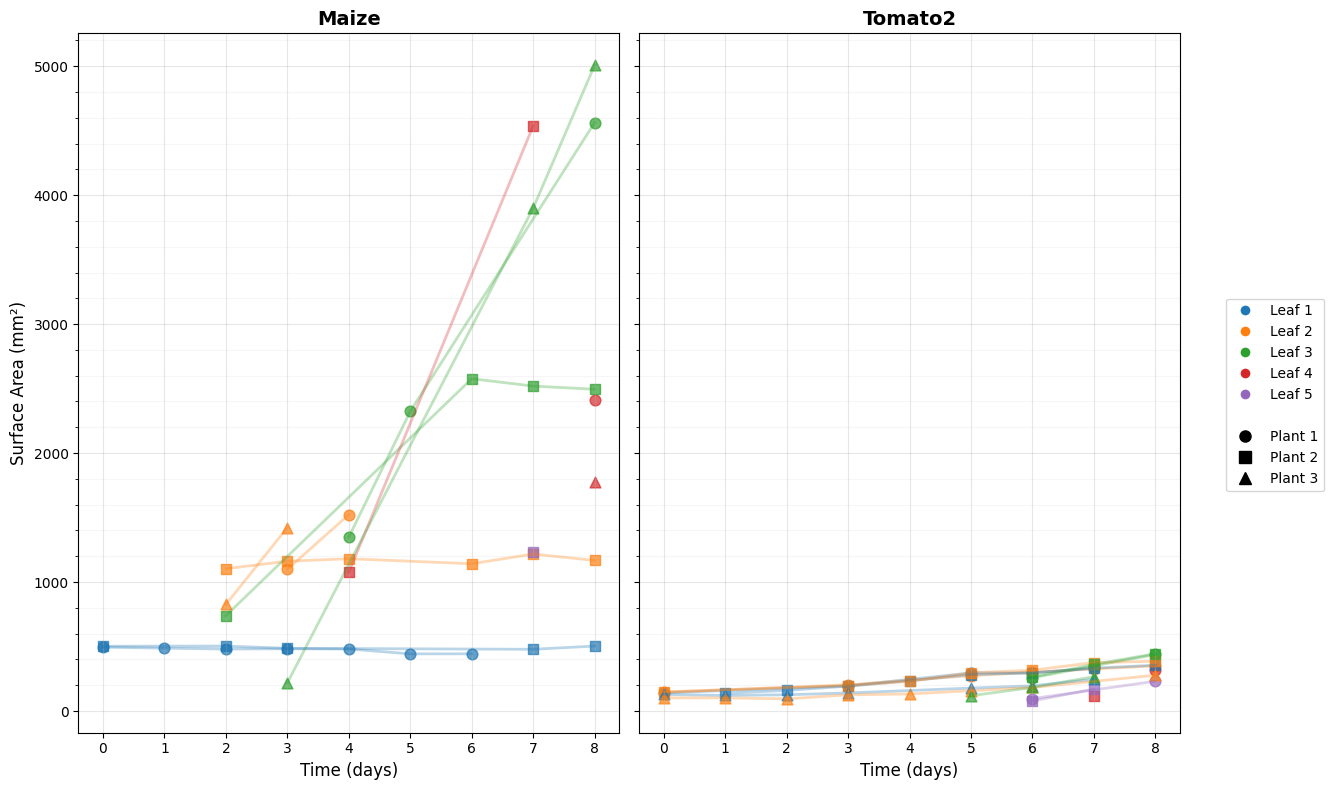


Summary by crop and plant:

MAIZE:
  Plant 1: 13 measurements, Area range: 443.3 - 4562.6 mm²
    Leaf 1: 7 measurements, Area: 443.3 - 495.3 mm²
    Leaf 2: 2 measurements, Area: 1099.3 - 1522.9 mm²
    Leaf 3: 3 measurements, Area: 1348.9 - 4562.6 mm²
    Leaf 4: 1 measurements, Area: 2415.1 - 2415.1 mm²
  Plant 2: 18 measurements, Area range: 478.7 - 4537.7 mm²
    Leaf 1: 5 measurements, Area: 478.7 - 503.9 mm²
    Leaf 2: 6 measurements, Area: 1103.8 - 1217.2 mm²
    Leaf 3: 4 measurements, Area: 739.7 - 2576.7 mm²
    Leaf 4: 2 measurements, Area: 1077.5 - 4537.7 mm²
    Leaf 5: 1 measurements, Area: 1230.4 - 1230.4 mm²
  Plant 3: 6 measurements, Area range: 218.7 - 5007.9 mm²
    Leaf 2: 2 measurements, Area: 826.7 - 1423.0 mm²
    Leaf 3: 3 measurements, Area: 218.7 - 5007.9 mm²
    Leaf 4: 1 measurements, Area: 1779.3 - 1779.3 mm²

TOMATO2:
  Plant 1: 17 measurements, Area range: 96.3 - 438.6 mm²
    Leaf 1: 5 measurements, Area: 140.2 - 331.2 mm²
    Leaf 2: 6 measurements, 

In [5]:
# Check if we have data to plot
if len(plot_df) == 0:
    print("No data available for plotting. Please check the data extraction step above.")
else:
    # Get unique crops and set up side-by-side subplots
    crops = sorted(plot_df['crop'].unique())
    n_crops = len(crops)
    
    fig, axes = plt.subplots(1, n_crops, figsize=(6 * n_crops, 8), sharey=True)
    if n_crops == 1:
        axes = [axes]  # Make it a list for consistency
    
    # Define colors for each leaf number (use enough colors for all possible leaf numbers)
    colors = plt.cm.tab10(np.arange(10))
    markers = ['o', 's', '^', 'D', 'v']  # Different markers for different plants
    
    for crop_idx, crop in enumerate(crops):
        ax = axes[crop_idx]
        crop_data = plot_df[plot_df['crop'] == crop]
        
        # Get unique plants and leaf numbers for this crop
        plants = sorted(crop_data['plant'].unique())
        leaf_numbers = sorted(crop_data['leaf'].unique())
        
        print(f"\n{crop.upper()} - Plants: {plants}, Leaf numbers: {leaf_numbers}")
        
        # Plot each combination of plant and leaf number
        for i, plant in enumerate(plants):
            for leaf_num in leaf_numbers:
                # Filter data for this plant and leaf number
                data_subset = crop_data[(crop_data['plant'] == plant) & (crop_data['leaf'] == leaf_num)]
                
                if len(data_subset) > 0:
                    ax.scatter(data_subset['day'], data_subset['surface_area_mm2'], 
                             color=colors[leaf_num-1], marker=markers[i % len(markers)], s=60,
                             alpha=0.7)
                    
                    # Connect points for the same leaf within a plant with lines
                    if len(data_subset) > 1:
                        sorted_data = data_subset.sort_values('day')
                        ax.plot(sorted_data['day'], sorted_data['surface_area_mm2'], 
                               color=colors[leaf_num-1], linestyle='-', alpha=0.3, linewidth=2)
        
        # Formatting for each subplot
        ax.set_xlabel('Time (days)', fontsize=12)
        if crop_idx == 0:
            ax.set_ylabel('Surface Area (mm²)', fontsize=12)
        
        ax.set_title(f'{crop.capitalize()}', fontsize=14, fontweight='bold')
        
        # Add minor ticks and grid
        from matplotlib.ticker import AutoMinorLocator
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.grid(True, alpha=0.3)
        ax.grid(True, which='minor', alpha=0.1)
    
    # Create unified legend for all subplots
    # Collect all unique leaf numbers and plants across all crops
    all_leaf_numbers = sorted(plot_df['leaf'].unique())
    all_plants = sorted(plot_df['plant'].unique())
    
    legend_elements = []
    
    # Add leaf number colors to legend
    for leaf_num in all_leaf_numbers:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=colors[leaf_num-1], markersize=8,
                                     label=f'Leaf {leaf_num}'))
    
    # Add separator
    legend_elements.append(Line2D([0], [0], marker='', color='w', label=''))
    
    # Add plant markers to legend
    for i, plant in enumerate(all_plants):
        legend_elements.append(Line2D([0], [0], marker=markers[i % len(markers)], color='k', 
                                     markersize=8, linestyle='None',
                                     label=f'Plant {plant}'))
    
    # Place legend to the right of all subplots
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.5), loc='center left')
    
    plt.tight_layout()
    
    # Save the figure
    Path("../figures").mkdir(parents=True, exist_ok=True)
    #plt.savefig("../figures/trackplant3D_gt_leaves_area_timeseries_by_species.pdf", dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics by crop and plant
    print("\nSummary by crop and plant:")
    for crop in crops:
        crop_data = plot_df[plot_df['crop'] == crop]
        print(f"\n{crop.upper()}:")
        for plant in sorted(crop_data['plant'].unique()):
            plant_data = crop_data[crop_data['plant'] == plant]
            print(f"  Plant {plant}: {len(plant_data)} measurements, "
                  f"Area range: {plant_data['surface_area_mm2'].min():.1f} - {plant_data['surface_area_mm2'].max():.1f} mm²")
            
            # Print leaf-level stats for this plant
            for leaf_num in sorted(plant_data['leaf'].unique()):
                leaf_data = plant_data[plant_data['leaf'] == leaf_num]
                print(f"    Leaf {leaf_num}: {len(leaf_data)} measurements, "
                      f"Area: {leaf_data['surface_area_mm2'].min():.1f} - {leaf_data['surface_area_mm2'].max():.1f} mm²")

### Get good leaves sequences names

In [6]:
good_leaves.groupby(['crop', 'leaf_sequence_id']
    ).agg({'file_name': 'count'}
    ).rename(columns={'file_name': 'num_measurements'}
    ).sort_values(['crop', 'num_measurements'], ascending=[True, False]
    ).reset_index()

,crop,leaf_sequence_id,num_measurements
0,maize,0,7
1,maize,5,6
2,maize,4,5
3,maize,6,4
4,maize,2,3
5,maize,11,3
6,maize,1,2
7,maize,7,2
8,maize,10,2
9,maize,3,1


In [7]:
dataset_path = Path("../data/TrackPlant3D")
leaf_dataset = LeafSequencesDataset(
    dataset_path, 
    min_timepoints=2,
    apply_pca_alignment=True
)

Applying PCA alignment to 256 leaf sequences...
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component
Reflection detected: flipping first principal component


In [8]:
maize_sequences = leaf_dataset.get_timeseries_by_crop('maize')
maize_sequences

[{'sequence_name': 'maize_control_plant1',
  'leaf_id': 1,
  'timepoints': [{'day': 0,
    'leaf_id': 1,
    'points': array([[ 6.528425, -4.4796  ,  3.937625],
           [ 6.42105 , -8.4412  , 20.428499],
           [-2.45315 , -4.028133, 12.709   ],
           ...,
           [ 7.125534, -6.243192,  7.31445 ],
           [-0.10225 , -2.6813  ,  3.67935 ],
           [-5.865   ,  1.13345 , -2.873725]], shape=(5594, 3)),
    'dense_points': array([[ -5.07479513,   7.647277  , -14.98226622],
           [ -5.23639513,   7.580777  , -15.07376622],
           [ -5.27159513,   7.519777  , -15.13956622],
           ...,
           [ -6.60379513,   4.461477  , -16.12056622],
           [ -6.51649513,   4.461577  , -16.15536622],
           [ -6.42809513,   4.458977  , -16.18886622]], shape=(155504, 3)),
    'leaf_tip': array([ 7.34715 , -9.7354  , 19.847799]),
    'file_path': PosixPath('../data/TrackPlant3D/gt_corrected_v1/maize/1_maize_control_plant1_D00.txt')},
   {'day': 1,
    'leaf_id'

In [9]:
tomato_sequences = leaf_dataset.get_timeseries_by_crop('tomato2')
tomato_sequences

[{'sequence_name': 'tomato2_control_plant1',
  'leaf_id': 1,
  'timepoints': [{'day': 0,
    'leaf_id': 1,
    'points': array([[22.565651,  1.25435 , 11.69835 ],
           [ 9.933701,  4.2085  , 13.021749],
           [15.08335 , -2.03885 , 12.45535 ],
           ...,
           [21.956852,  2.13887 , 12.567369],
           [16.370651,  0.3748  , 13.20385 ],
           [ 6.329575, -2.449694, 11.61502 ]], shape=(3521, 3)),
    'dense_points': array([[ 2.56478271,  0.47057462,  9.45577724],
           [ 2.58638271,  0.38867462,  9.42887724],
           [ 2.64678271,  0.04377462,  9.41807724],
           ...,
           [13.84728271,  4.66357462, 13.41777724],
           [13.92338271,  4.65127462, 13.43807724],
           [14.03568271,  4.63167462, 13.46987724]], shape=(62501, 3)),
    'leaf_tip': None,
    'file_path': PosixPath('../data/TrackPlant3D/gt_corrected_v1/tomato/352_tomato2_control_plant1_D00.txt')},
   {'day': 1,
    'leaf_id': 1,
    'points': array([[23.55624996,  2.67471

#### Match sequences to dataloader indices

In [10]:
# Get sequences with more than 5 measurements
sequences_with_5plus = good_leaves.groupby(['crop', 'leaf_sequence_id']).agg({
    'file_name': 'count',
    'plant': 'first',  # Add plant info
    'treatment': 'first',  # Add treatment info
    'leaf': 'first'    # Add leaf info
}).rename(columns={'file_name': 'num_measurements'}).query('num_measurements >= 5').reset_index()

print(f"Found {len(sequences_with_5plus)} sequences with 5+ measurements:")
print(sequences_with_5plus)

# Create a mapping from good_leaves to dataloader sequences
# TODO: merge into dataloader and make logic easier for finding sequences
def find_matching_sequence(crop, treatment, plant, leaf, full_dataset):
    """Find matching sequence in the dataloader based on crop, treatment, plant, and leaf"""
    # Expected sequence name pattern
    expected_prefix = f'{crop}_{treatment}_plant{plant}'
    
    # Search through the full dataset to get the correct index
    for i in range(len(full_dataset)):
        seq = full_dataset[i]
        seq_name = seq['sequence_name']
        print(f"  Checking sequence: {seq_name}")
        
        # Check if sequence name starts with expected prefix
        if seq_name.startswith(expected_prefix):
            if leaf == seq['leaf_id']:
                print(f"    ✓ Match found! Leaf {leaf} in sequence {seq_name}")
                return i, seq
            print(f"    - Sequence matches plant but doesn't contain leaf {leaf}")
        else:
            print(f"    - Doesn't match expected prefix: {expected_prefix}")
                
    return None, None

# Match each good sequence with dataloader sequences
matched_sequences = {}

for _, row in sequences_with_5plus.iterrows():
    crop = row['crop']
    treatment = row['treatment']
    leaf_seq_id = row['leaf_sequence_id']
    plant = row['plant']
    leaf = row['leaf']
    
    print(f"\nLooking for: {crop}_{treatment}_plant{plant} with leaf{leaf}")
    
    # Find matching sequence in the full dataset
    seq_idx, seq_data = find_matching_sequence(crop, treatment, plant, leaf, leaf_dataset)
    
    if seq_data is not None:
        matched_sequences[leaf_seq_id] = {
            'crop': crop,
            'treatment': treatment,
            'plant': plant, 
            'leaf': leaf,
            'dataloader_idx': seq_idx,
            'sequence_name': seq_data['sequence_name'],
            'num_timepoints': len(seq_data['timepoints']),
            'num_measurements': row['num_measurements']
        }
        print(f"✓ Matched leaf_sequence_id {leaf_seq_id}: {seq_data['sequence_name']} ({len(seq_data['timepoints'])} timepoints)")
    else:
        print(f"✗ No match found for leaf_sequence_id {leaf_seq_id}: {crop}_{treatment}_plant{plant} leaf{leaf}")

print(f"\nSuccessfully matched {len(matched_sequences)} out of {len(sequences_with_5plus)} sequences")

Found 9 sequences with 5+ measurements:
      crop  leaf_sequence_id  num_measurements  plant treatment  leaf
0    maize                 0                 7      1   control     1
1    maize                 4                 5      2   control     1
2    maize                 5                 6      2   control     2
3  tomato2                13                 5      1   control     1
4  tomato2                14                 6      1   control     2
5  tomato2                21                 8      2   control     1
6  tomato2                22                 7      2   control     2
7  tomato2                31                 7      3   control     1
8  tomato2                32                 8      3   control     2

Looking for: maize_control_plant1 with leaf1
  Checking sequence: maize_control_plant1
    ✓ Match found! Leaf 1 in sequence maize_control_plant1
✓ Matched leaf_sequence_id 0: maize_control_plant1 (9 timepoints)

Looking for: maize_control_plant2 with leaf1
 

In [11]:
sequences_with_5plus

,crop,leaf_sequence_id,num_measurements,plant,treatment,leaf
0,maize,0,7,1,control,1
1,maize,4,5,2,control,1
2,maize,5,6,2,control,2
3,tomato2,13,5,1,control,1
4,tomato2,14,6,1,control,2
5,tomato2,21,8,2,control,1
6,tomato2,22,7,2,control,2
7,tomato2,31,7,3,control,1
8,tomato2,32,8,3,control,2


In [12]:
leaf_dataset[0]

{'sequence_name': 'maize_control_plant1',
 'leaf_id': 1,
 'timepoints': [{'day': 0,
   'leaf_id': 1,
   'points': array([[ 6.528425, -4.4796  ,  3.937625],
          [ 6.42105 , -8.4412  , 20.428499],
          [-2.45315 , -4.028133, 12.709   ],
          ...,
          [ 7.125534, -6.243192,  7.31445 ],
          [-0.10225 , -2.6813  ,  3.67935 ],
          [-5.865   ,  1.13345 , -2.873725]], shape=(5594, 3)),
   'dense_points': array([[ -5.07479513,   7.647277  , -14.98226622],
          [ -5.23639513,   7.580777  , -15.07376622],
          [ -5.27159513,   7.519777  , -15.13956622],
          ...,
          [ -6.60379513,   4.461477  , -16.12056622],
          [ -6.51649513,   4.461577  , -16.15536622],
          [ -6.42809513,   4.458977  , -16.18886622]], shape=(155504, 3)),
   'leaf_tip': array([ 7.34715 , -9.7354  , 19.847799]),
   'file_path': PosixPath('../data/TrackPlant3D/gt_corrected_v1/maize/1_maize_control_plant1_D00.txt')},
  {'day': 1,
   'leaf_id': 1,
   'points': arra

In [13]:
matched_sequences

{0: {'crop': 'maize',
  'treatment': 'control',
  'plant': 1,
  'leaf': 1,
  'dataloader_idx': 0,
  'sequence_name': 'maize_control_plant1',
  'num_timepoints': 9,
  'num_measurements': 7},
 4: {'crop': 'maize',
  'treatment': 'control',
  'plant': 2,
  'leaf': 1,
  'dataloader_idx': 8,
  'sequence_name': 'maize_control_plant2',
  'num_timepoints': 9,
  'num_measurements': 5},
 5: {'crop': 'maize',
  'treatment': 'control',
  'plant': 2,
  'leaf': 2,
  'dataloader_idx': 9,
  'sequence_name': 'maize_control_plant2',
  'num_timepoints': 9,
  'num_measurements': 6},
 13: {'crop': 'tomato2',
  'treatment': 'control',
  'plant': 1,
  'leaf': 1,
  'dataloader_idx': 109,
  'sequence_name': 'tomato2_control_plant1',
  'num_timepoints': 9,
  'num_measurements': 5},
 14: {'crop': 'tomato2',
  'treatment': 'control',
  'plant': 1,
  'leaf': 2,
  'dataloader_idx': 110,
  'sequence_name': 'tomato2_control_plant1',
  'num_timepoints': 9,
  'num_measurements': 6},
 21: {'crop': 'tomato2',
  'treatmen

In [20]:
# Test that the fixed dataloader indices work correctly
print("Testing corrected dataloader indices:")

for seq_id, match_info in list(matched_sequences.items()):  # Test first 3
    dataloader_idx = match_info['dataloader_idx']
    expected_name = match_info['sequence_name']
    
    # Get the sequence from the dataset
    actual_sequence = leaf_dataset[dataloader_idx]
    actual_name = actual_sequence['sequence_name']
    
    print(f"Sequence ID {seq_id}: Expected '{expected_name}', Got '{actual_name}' - {'✓' if expected_name == actual_name else '✗'}")

print("\nAll indices are now correctly pointing to the full dataset!")

Testing corrected dataloader indices:
Sequence ID 0: Expected 'maize_control_plant1', Got 'maize_control_plant1' - ✓
Sequence ID 4: Expected 'maize_control_plant2', Got 'maize_control_plant2' - ✓
Sequence ID 5: Expected 'maize_control_plant2', Got 'maize_control_plant2' - ✓
Sequence ID 13: Expected 'tomato2_control_plant1', Got 'tomato2_control_plant1' - ✓
Sequence ID 14: Expected 'tomato2_control_plant1', Got 'tomato2_control_plant1' - ✓
Sequence ID 21: Expected 'tomato2_control_plant2', Got 'tomato2_control_plant2' - ✓
Sequence ID 22: Expected 'tomato2_control_plant2', Got 'tomato2_control_plant2' - ✓
Sequence ID 31: Expected 'tomato2_control_plant3', Got 'tomato2_control_plant3' - ✓
Sequence ID 32: Expected 'tomato2_control_plant3', Got 'tomato2_control_plant3' - ✓

All indices are now correctly pointing to the full dataset!


#### Visualize good sequences

In [14]:
# Example: Load and visualize a specific sequence
# Pick the first matched sequence as an example
if matched_sequences:
    # Get the first matched sequence
    example_seq_id = list(matched_sequences.keys())[0]
    match_info = matched_sequences[example_seq_id]
    
    print(f"Loading sequence {example_seq_id}: {match_info['sequence_name']}")
    
    # Get the sequence data from the appropriate dataloader
    if match_info['crop'] == 'maize':
        sequence_data = maize_sequences[match_info['dataloader_idx']]
    else:
        sequence_data = tomato_sequences[match_info['dataloader_idx']]
    
    # Show available timepoints
    print(f"Available timepoints: {len(sequence_data['timepoints'])}")
    for i, timepoint in enumerate(sequence_data['timepoints']):
        print(f"  Timepoint {i}: {timepoint['file_path'].name}, {timepoint['points'].shape[0]} points")
    
    # Load a specific timepoint (e.g., the first one)
    timepoint_data = sequence_data['timepoints'][0]
    points = timepoint_data['points']  # This is your numpy array of points
    
    print(f"\nLoaded point cloud shape: {points.shape}")
    print(f"Point cloud min: {points.min(axis=0)}")
    print(f"Point cloud max: {points.max(axis=0)}")
else:
    print("No matched sequences found to demonstrate with")

Loading sequence 0: maize_control_plant1
Available timepoints: 9
  Timepoint 0: 1_maize_control_plant1_D00.txt, 5594 points
  Timepoint 1: 2_maize_control_plant1_D01.txt, 3544 points
  Timepoint 2: 3_maize_control_plant1_D02.txt, 2445 points
  Timepoint 3: 4_maize_control_plant1_D03.txt, 1662 points
  Timepoint 4: 5_maize_control_plant1_D04.txt, 1221 points
  Timepoint 5: 6_maize_control_plant1_D05.txt, 928 points
  Timepoint 6: 7_maize_control_plant1_D06.txt, 777 points
  Timepoint 7: 8_maize_control_plant1_D07.txt, 325 points
  Timepoint 8: 9_maize_control_plant1_D08.txt, 445 points

Loaded point cloud shape: (5594, 3)
Point cloud min: [ -8.74185 -10.0644  -15.075  ]
Point cloud max: [ 9.65365   6.504034 20.428499]


In [ ]:
for _ , value in matched_sequences.items():
    idx = value['dataloader_idx']
    visualize_leaf_sequence(leaf_dataset[idx])

In [16]:
matched_sequences

{0: {'crop': 'maize',
  'treatment': 'control',
  'plant': 1,
  'leaf': 1,
  'dataloader_idx': 0,
  'sequence_name': 'maize_control_plant1',
  'num_timepoints': 9,
  'num_measurements': 7},
 4: {'crop': 'maize',
  'treatment': 'control',
  'plant': 2,
  'leaf': 1,
  'dataloader_idx': 8,
  'sequence_name': 'maize_control_plant2',
  'num_timepoints': 9,
  'num_measurements': 5},
 5: {'crop': 'maize',
  'treatment': 'control',
  'plant': 2,
  'leaf': 2,
  'dataloader_idx': 9,
  'sequence_name': 'maize_control_plant2',
  'num_timepoints': 9,
  'num_measurements': 6},
 13: {'crop': 'tomato2',
  'treatment': 'control',
  'plant': 1,
  'leaf': 1,
  'dataloader_idx': 109,
  'sequence_name': 'tomato2_control_plant1',
  'num_timepoints': 9,
  'num_measurements': 5},
 14: {'crop': 'tomato2',
  'treatment': 'control',
  'plant': 1,
  'leaf': 2,
  'dataloader_idx': 110,
  'sequence_name': 'tomato2_control_plant1',
  'num_timepoints': 9,
  'num_measurements': 6},
 21: {'crop': 'tomato2',
  'treatmen